# Question 5 — Gaussian Filtering
- (a) Compute normalized 5×5 Gaussian kernel (σ=2)
- (b) Visualize 51×51 kernel as 3D surface
- (c) Apply manually using filter2D
- (d) Apply using cv.GaussianBlur()

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
%matplotlib inline

def show_gray(img, title=''):
    plt.figure(figsize=(6, 5))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [2]:
# (a) Normalized 5×5 Gaussian kernel
def gaussian_kernel(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    X, Y = np.meshgrid(ax, ax)
    kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return kernel / kernel.sum()

sigma = 2
g5 = gaussian_kernel(5, sigma)
print(f'5×5 Gaussian kernel (σ={sigma}):')
print(np.array2string(g5, precision=4, suppress_small=True))
print(f'Sum = {g5.sum():.6f}')

5×5 Gaussian kernel (σ=2):
[[0.0232 0.0338 0.0383 0.0338 0.0232]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0383 0.0558 0.0632 0.0558 0.0383]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0232 0.0338 0.0383 0.0338 0.0232]]
Sum = 1.000000


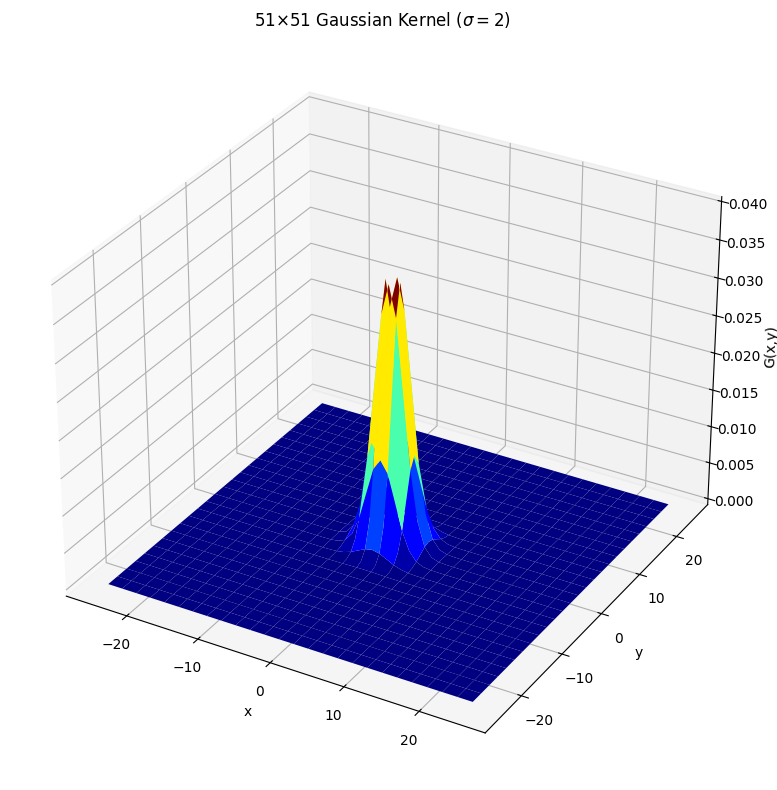

In [3]:
# (b) 3D surface plot of 51×51 kernel
g51 = gaussian_kernel(51, sigma)
ax_vals = np.arange(-(51 // 2), 51 // 2 + 1)
X, Y = np.meshgrid(ax_vals, ax_vals)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, g51, cmap=cm.jet, linewidth=0, antialiased=True)
ax.set_title(rf'51×51 Gaussian Kernel ($\sigma={sigma}$)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('G(x,y)')
plt.tight_layout()
plt.savefig('outputs/q5b_surface.png', dpi=150, bbox_inches='tight')
plt.show()

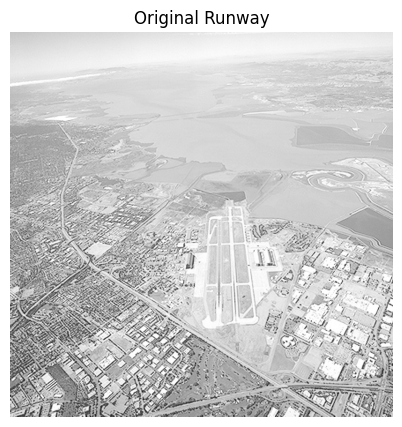

In [4]:
# Load runway image
img = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert img is not None
show_gray(img, 'Original Runway')

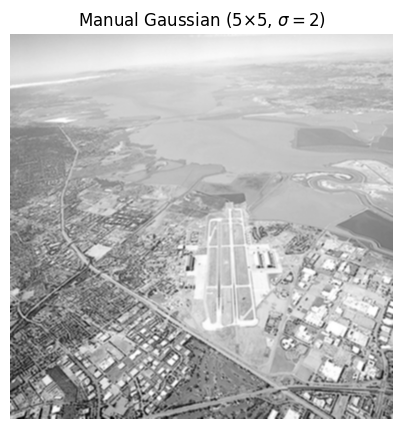

True

In [5]:
# (c) Manual Gaussian smoothing using filter2D
img_manual = cv.filter2D(img, -1, g5.astype(np.float32))
show_gray(img_manual, rf'Manual Gaussian (5×5, $\sigma={sigma}$)')
cv.imwrite('outputs/q5c_manual_gaussian.png', img_manual)

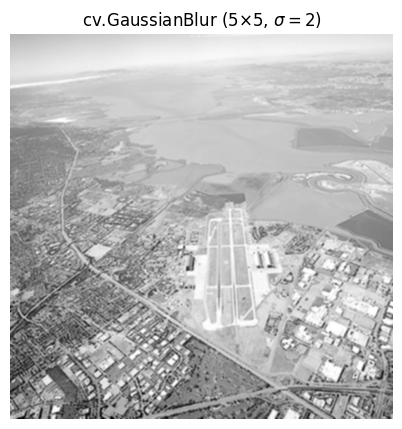

Max pixel difference vs cv.GaussianBlur: 1
Both methods produce visually identical results.


In [6]:
# (d) OpenCV GaussianBlur
img_cv = cv.GaussianBlur(img, (5, 5), sigma)
show_gray(img_cv, rf'cv.GaussianBlur (5×5, $\sigma={sigma}$)')
cv.imwrite('outputs/q5d_opencv_gaussian.png', img_cv)

diff = np.abs(img_manual.astype(int) - img_cv.astype(int))
print(f'Max pixel difference vs cv.GaussianBlur: {diff.max()}')
print('Both methods produce visually identical results.')